# 05. Modeling RQ3: ROI Prediction (预测模型)

**Research Question:** Can we predict a movie's ROI based on its Budget, Release Date, Runtime, and Genre?
**核心问题:** 结合预算、档期和类型等特征，我们能否建立模型预测一部电影的ROI？

**Steps:**
1. Load Data (加载数据)
2. Feature Engineering (特征工程: Budget, Runtime, Genres, Seasonality, Production Company Presence)
3. Train-Test Split (训练集与测试集划分)
4. Model Training (模型训练: Random Forest Regressor)
5. Evaluation (模型评估: MSE, R2 Score, Feature Importance)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ast

sns.set(style="whitegrid")

# Load Processed Data
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
df = pd.read_csv(PROCESSED_DATA_PATH)

# Parse list columns
list_cols = ['genres', 'production_companies']
for col in list_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Calculate ROI (if not present or recalculate to be safe)
# ROI = (Revenue - Budget) / Budget
df['roi'] = (df['revenue'] - df['budget']) / df['budget']

# Filter outliers for better modeling (e.g., extremely high ROI or low budget movies that skew results)
df = df[(df['budget'] > 10000) & (df['revenue'] > 10000)]
df = df[(df['roi'] > -1) & (df['roi'] < 50)]  # Keep ROI between -100% and 5000%

print(f"Data Loaded for Modeling: {df.shape}")
display(df.head(2))

Data Loaded for Modeling: (5646, 27)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","[Legendary Pictures, Syncopy, Warner Bros. Pic...","['United Kingdom', 'United States of America']","['English', 'French', 'Japanese', 'Swahili']","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","[Legendary Pictures, Syncopy, Lynda Obst Produ...","['United Kingdom', 'United States of America']",['English'],"rescue, future, spacecraft, race against time,...",2014.0,11.0,3.252904


## 2. Feature Engineering (特征工程)
We need to convert categorical variables (Genres, Production Companies) into numerical features.

In [2]:
# 1. One-Hot Encode Genres
df_genres = df['genres'].explode().str.get_dummies().groupby(level=0).sum()
df_model = pd.concat([df, df_genres], axis=1)

# 2. Production Company Count
df_model['prod_company_count'] = df['production_companies'].apply(len)

# 3. Seasonality (Month)
# We already have 'release_month'

# Select Features for Model
features = ['budget', 'runtime', 'release_month', 'prod_company_count'] + list(df_genres.columns)
target = 'roi'

# Handle missing values (runtime might have some)
df_model = df_model.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Features Shape: (5646, 23)
Target Shape: (5646,)


## 3. Model Training (模型训练)
Using Random Forest Regressor to predict ROI.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 21.2172
R2 Score: -0.0366


## 4. Feature Importance (特征重要性)
Which features matter most for predicting ROI?

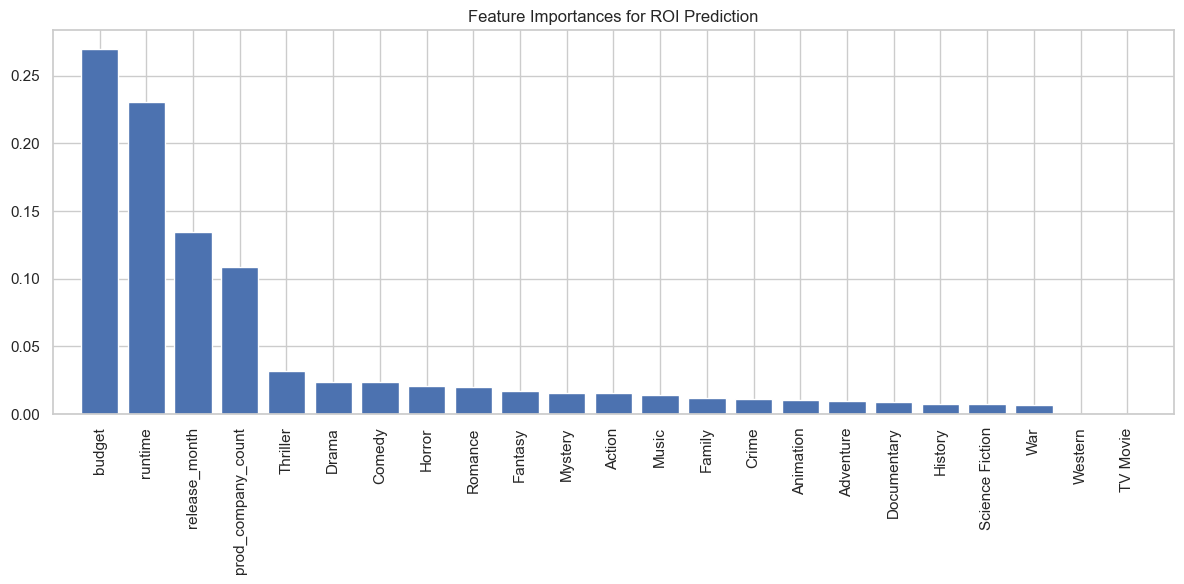

In [4]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances for ROI Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()